Name: Atharv Maheshwari <br>
Roll No. 23b1805 <br>

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import colors

In [43]:
#defining parameters for haldane model

# nearest neighbour vectors
a1 = np.array([0, -1])
a2 = np.array([np.sqrt(3)/2, 1/2])
a3 = np.array([-np.sqrt(3)/2, 1/2])

avec = [a1, a2, a3]

# next nearest neighbour vectors
b1 = a2 - a3
b2 = a3 - a1
b3 = a1 - a2

bvec = [b1, b2, b3]

# hopping parameters
t1 = 1
t2 = 0.1
phi = np.pi/3
delta = 0.1

In [ ]:
def Hk(kx, ky):
    g = 0+0j
    f = 0.0
    h0 = 0.0

    for a in avec:
        g += np.exp(1j*(kx*a[0] + ky*a[1]))
    g *= t1
    
    for b in bvec:
        kdot = kx*b[0] + ky*b[1]
        f  += np.sin(kdot)
        h0 += np.cos(kdot)

    f  *= 2*t2*np.sin(phi)   # sigma_z term
    h0 *= 2*t2*np.cos(phi)   # identity term
    
    H = np.array([
        [delta + f + h0, g],
        [np.conj(g), -delta - f + h0]
    ], dtype=complex)

    return H

In [45]:
Nk = 200   # grid resolution
dk=2*np.pi/(Nk-1)
kx_vals = np.linspace(-np.pi, np.pi, Nk)
ky_vals = np.linspace(-np.pi, np.pi, Nk)

eigvec = np.zeros((Nk,Nk,2,2), dtype=complex)

for i,kx in enumerate(kx_vals):
    for j,ky in enumerate(ky_vals):

        w,v = np.linalg.eigh(Hk(kx,ky))

        eigvec[i,j,:,0] = v[:,0]   # lower band
        eigvec[i,j,:,1] = v[:,1]   # upper band

In [ ]:
def berry_curvature(kx, ky, dk):

    H = Hk(kx, ky)
    
    E, U = np.linalg.eigh(H) # eigenvalues and eigenvectors

    # Hamiltonian derivatives
    Hx = (Hk(kx+dk, ky) - Hk(kx-dk, ky))/(2*dk)
    Hy = (Hk(kx, ky+dk) - Hk(kx, ky-dk))/(2*dk)

    F = np.zeros(2) #to account for lower and upper band
    for n in range(2):
        for m in range(2):
            if m != n:
                num = np.vdot(U[:,n], Hx @ U[:,m]) * \
                      np.vdot(U[:,m], Hy @ U[:,n])
                F[n] += -2*np.imag(num) / (E[m]-E[n])**2
    return F

# def berry_curvature(eigvec_band):

#     Ux = np.zeros((Nk,Nk), dtype=complex)
#     Uy = np.zeros((Nk,Nk), dtype=complex)

#     for i in range(Nk):
#         for j in range(Nk):

#             u = eigvec_band[i,j]

#             u_x = eigvec_band[(i+1)%Nk, j]
#             u_y = eigvec_band[i,(j+1)%Nk]

#             Ux[i,j] = np.vdot(u,u_x)
#             Uy[i,j] = np.vdot(u,u_y)

#             Ux[i,j] /= abs(Ux[i,j])
#             Uy[i,j] /= abs(Uy[i,j])

#     F = np.zeros((Nk,Nk))

#     for i in range(Nk):
#         for j in range(Nk):

#             term = Ux[i,j]*Uy[(i+1)%Nk,j] * \
#                    np.conj(Ux[i,(j+1)%Nk]) * \
#                    np.conj(Uy[i,j])

#             F[i,j] = np.angle(term)

#     return F

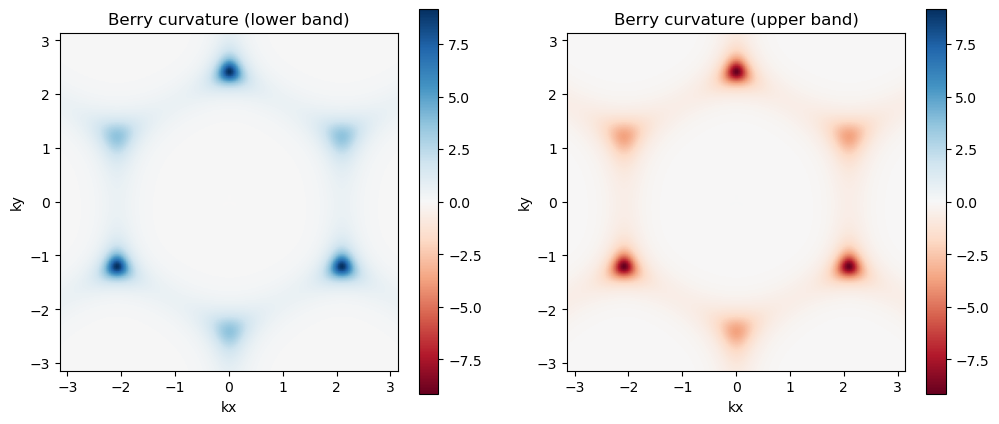

In [47]:
F_lower = np.zeros((Nk,Nk))
F_upper = np.zeros((Nk,Nk))

for i in range(Nk):
    for j in range(Nk):
        F = berry_curvature(kx_vals[i], ky_vals[j],dk)
        F_lower[i,j] = F[0]
        F_upper[i,j] = F[1]

# F_lower = berry_curvature(eigvec[:,:,:,0])
# F_upper = berry_curvature(eigvec[:,:,:,1])

maxF = max(abs(F_lower.min()), abs(F_lower.max()),
           abs(F_upper.min()), abs(F_upper.max()))

norm = colors.TwoSlopeNorm(vmin=-maxF, vcenter=0, vmax=maxF)

# norm = colors.SymLogNorm(
#     linthresh=5e-4,   # region around zero that stays linear
#     linscale=0.5,
#     vmin=-maxF,
#     vmax=maxF,
#     base=2
# )

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(F_lower,
           origin="lower",
           extent=[-np.pi,np.pi,-np.pi,np.pi],
           cmap="RdBu",
           norm=norm)
plt.title("Berry curvature (lower band)")
plt.xlabel("kx")
plt.ylabel("ky")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(F_upper,
           origin="lower",
           extent=[-np.pi,np.pi,-np.pi,np.pi],
           cmap="RdBu",
           norm=norm)
plt.title("Berry curvature (upper band)")
plt.xlabel("kx")
plt.ylabel("ky")
plt.colorbar()

plt.show()

In [48]:
E1 = np.zeros((Nk,Nk))
E2 = np.zeros((Nk,Nk))

for i,kx in enumerate(kx_vals):
    for j,ky in enumerate(ky_vals):

        w,_ = np.linalg.eigh(Hk(kx,ky))

        E1[i,j] = w[0]
        E2[i,j] = w[1]

In [49]:
# Normalize Berry curvature for gradient coloring
norm_lower = (F_lower - np.min(F_lower)) / np.ptp(F_lower)
norm_upper = (F_upper - np.min(F_upper)) / np.ptp(F_upper)

kxg, kyg = np.meshgrid(kx_vals, ky_vals)

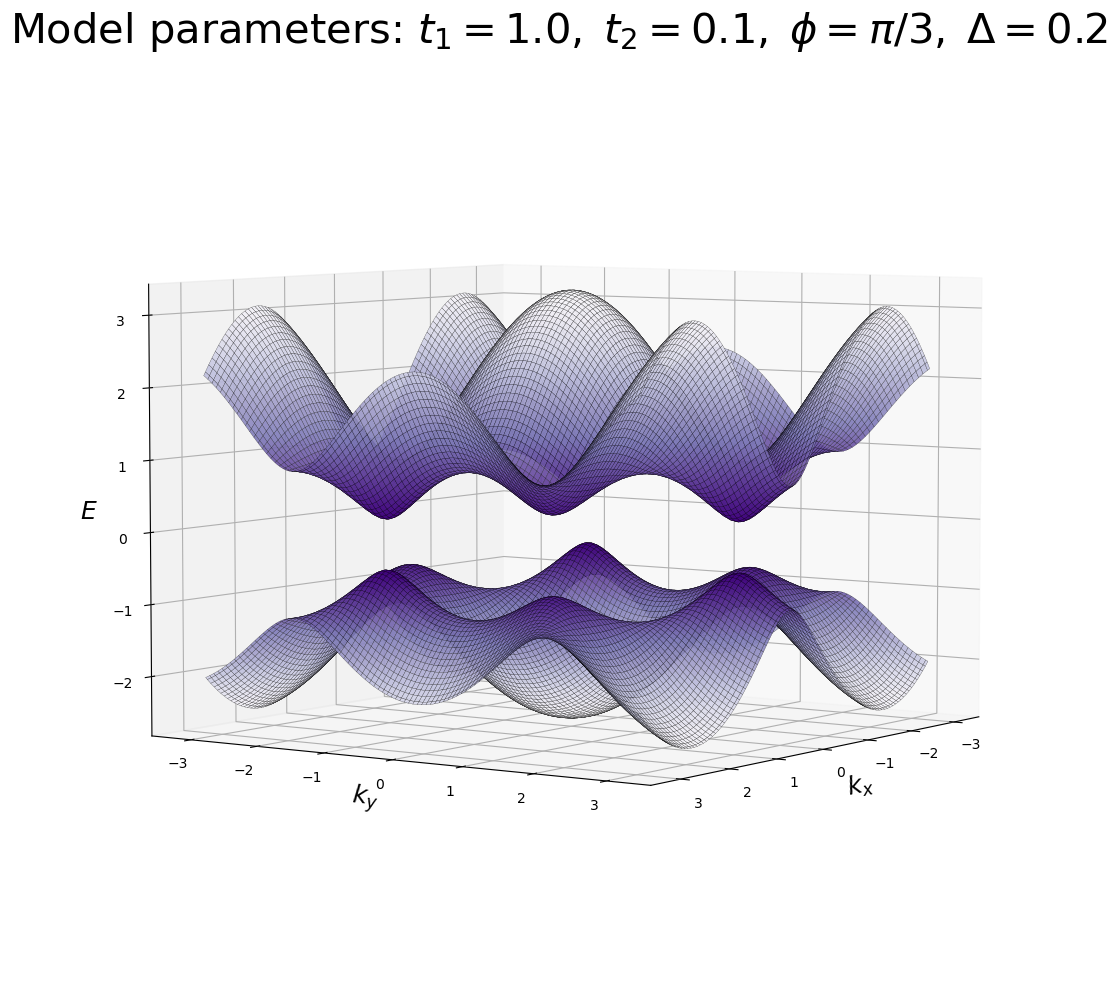

In [50]:
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111, projection='3d')

# upper band
surf1 = ax.plot_surface(kxg, kyg, E2, cmap='Purples_r', edgecolor='k', linewidth=0.15, rstride=2, cstride=2, alpha=0.9)

# lower band
surf2 = ax.plot_surface(kxg, kyg, E1, cmap='Purples', edgecolor='k', linewidth=0.15, rstride=2, cstride=2, alpha=0.9)

ax.set_xlabel(r'$k_x$', fontsize=18)
ax.set_ylabel(r'$k_y$', fontsize=18)
ax.set_zlabel(r'$E$', fontsize=18)
# ax.set_xlim(-np.pi,np.pi)
# ax.set_ylim(-np.pi,np.pi)

ax.view_init(elev=5, azim=35) # VIEWING ANGLE

plt.title(r"Model parameters: $t_1=1.0,\; t_2=0.1,\; \phi =\pi/3, \; \Delta =0.2$", fontsize=30)

plt.tight_layout()
plt.show()

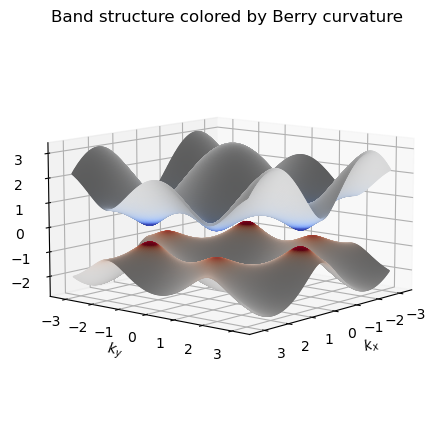

In [51]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111, projection='3d')

scale = 2   # amplify curvature contrast

maxF = max(abs(F_lower.min()), abs(F_lower.max()))

norm = colors.TwoSlopeNorm(
    vmin=-maxF/scale,
    vcenter=0,
    vmax=maxF/scale
)

# norm = colors.SymLogNorm(
#     linthresh=1e-3,   # region around zero that stays linear
#     linscale=1,
#     vmin=-maxF,
#     vmax=maxF,
#     base=2
# )

surf1 = ax.plot_surface(
    kxg, kyg, E1,
    facecolors=plt.cm.coolwarm(norm(F_lower)),
    edgecolor='none',
    antialiased=True,
    rstride=1,
    cstride=1
)

surf2 = ax.plot_surface(
    kxg, kyg, E2,
    facecolors=plt.cm.coolwarm(norm(F_upper)),
    edgecolor='none',
    antialiased=True,
    rstride=1,
    cstride=1
)

ax.set_xlabel("$k_x$")
ax.set_ylabel("$k_y$")
ax.set_zlabel("Energy")

# VIEWING ANGLE
ax.view_init(elev=10, azim=40)

# better aspect ratio
ax.set_box_aspect((1,1,0.6))

plt.title("Band structure colored by Berry curvature")

plt.show()

In [52]:
dkx = kx_vals[1] - kx_vals[0]
dky = ky_vals[1] - ky_vals[0]

In [53]:
def inside_BZ(kx, ky):
    kx = abs(kx)
    ky = abs(ky)
    if kx > 4*np.pi/(3*np.sqrt(3)):
        return False
    if ky > 2*np.pi/3:
        return False
    if ky > -np.sqrt(3)*kx + 4*np.pi/3:
        return False
    
    return True

chern_lower, chern_upper = 0, 0

for i,kx in enumerate(kx_vals):
    for j,ky in enumerate(ky_vals):
        if inside_BZ(kx,ky):
            chern_lower += F_lower[i,j]
            chern_upper += F_upper[i,j]

chern_lower *= dkx*dky/(2*np.pi)
chern_upper *= dkx*dky/(2*np.pi)

print("Chern number of upper band=", chern_upper.round(2))
print("Chern number of lower band=", chern_lower.round(2))

Chern number of upper band= -0.99
Chern number of lower band= 0.99


In [54]:
print("Chern number of upper band=", chern_upper.round(5))
print("Chern number of lower band=", chern_lower.round(5))

Chern number of upper band= -0.98546
Chern number of lower band= 0.98546


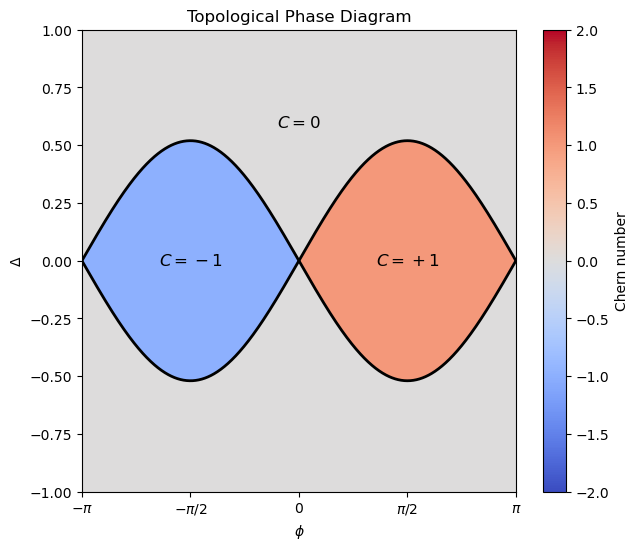

In [55]:
phi_vals = np.linspace(-np.pi, np.pi, 400)
delta_vals = np.linspace(-1, 1, 400)

PHI, DELTA = np.meshgrid(phi_vals, delta_vals)

boundary = 3*np.sqrt(3)*t2*np.sin(PHI)

chern = np.zeros_like(PHI)

# topological regions
chern[(np.abs(DELTA) < np.abs(boundary)) & (np.sin(PHI) > 0)] = 1
chern[(np.abs(DELTA) < np.abs(boundary)) & (np.sin(PHI) < 0)] = -1

plt.figure(figsize=(7,6))

plt.pcolormesh(
    PHI, DELTA, chern,
    cmap="coolwarm",
    shading="auto",
    vmin=-2, vmax=2
)

# phase boundaries
phi_line = np.linspace(-np.pi,np.pi,1000)
b = 3*np.sqrt(3)*t2*np.sin(phi_line)

plt.plot(phi_line, b, 'k', lw=2)
plt.plot(phi_line, -b, 'k', lw=2)

plt.colorbar(label="Chern number")

plt.xlabel(r"$\phi$")
plt.ylabel(r"$\Delta$")
plt.title("Topological Phase Diagram")

plt.xlim(-np.pi,np.pi)
plt.ylim(-1,1)

plt.xticks(
    [-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
    [r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"]
)

# Add labels for Chern number regions
plt.text(-1.57, 0, r"$C = -1$", color='black', fontsize=12, ha='center', va='center')
plt.text(0, 0.6, r"$C = 0$", color='black', fontsize=12, ha='center', va='center')
plt.text(1.57, 0, r"$C = +1$", color='black', fontsize=12, ha='center', va='center')

plt.show()

In [56]:
test_points = [
    (0.2, np.pi/2),
    (0.1, np.pi/3),
    (-0.2, np.pi/3),
    (0.8, np.pi/3),
    (-0.8, np.pi/3),
    (0.0, np.pi/4),
    (0.4, np.pi/6),
    (-0.4, np.pi/6),
    (0.2, -np.pi/3),
    (-0.2, -np.pi/3)
]

delta_test=np.linspace(-0.8,0.8,5)
phi_test=np.linspace(-0.85*np.pi,0.85*np.pi,5)
test_points_grid_delta, test_points_grid_phi= np.meshgrid(delta_test,phi_test)
test_points_grid=np.column_stack((test_points_grid_delta.ravel(),test_points_grid_phi.ravel()))

In [57]:
print(test_points_grid_delta, test_points_grid_phi)
print(test_points_grid)

[[-0.8 -0.4  0.   0.4  0.8]
 [-0.8 -0.4  0.   0.4  0.8]
 [-0.8 -0.4  0.   0.4  0.8]
 [-0.8 -0.4  0.   0.4  0.8]
 [-0.8 -0.4  0.   0.4  0.8]] [[-2.67035376 -2.67035376 -2.67035376 -2.67035376 -2.67035376]
 [-1.33517688 -1.33517688 -1.33517688 -1.33517688 -1.33517688]
 [ 0.          0.          0.          0.          0.        ]
 [ 1.33517688  1.33517688  1.33517688  1.33517688  1.33517688]
 [ 2.67035376  2.67035376  2.67035376  2.67035376  2.67035376]]
[[-0.8        -2.67035376]
 [-0.4        -2.67035376]
 [ 0.         -2.67035376]
 [ 0.4        -2.67035376]
 [ 0.8        -2.67035376]
 [-0.8        -1.33517688]
 [-0.4        -1.33517688]
 [ 0.         -1.33517688]
 [ 0.4        -1.33517688]
 [ 0.8        -1.33517688]
 [-0.8         0.        ]
 [-0.4         0.        ]
 [ 0.          0.        ]
 [ 0.4         0.        ]
 [ 0.8         0.        ]
 [-0.8         1.33517688]
 [-0.4         1.33517688]
 [ 0.          1.33517688]
 [ 0.4         1.33517688]
 [ 0.8         1.33517688]
 [-

In [81]:
chern_vals=[]
for delta_test, phi_test in test_points_grid:

    delta = delta_test
    phi = phi_test

    F_lower = np.zeros((Nk,Nk))

    for i in range(Nk):
        for j in range(Nk):

            F = berry_curvature(kx_vals[i], ky_vals[j], dk)
            F_lower[i,j] = F[0]

    chern = 0
    for i,kx in enumerate(kx_vals):
        for j,ky in enumerate(ky_vals):

            if inside_BZ(kx,ky):
                chern += F_lower[i,j]

    chern *= dkx*dky/(2*np.pi)

    chern_vals.append(chern.round(2))
    print(f"delta={delta_test:.2f}, phi={phi_test:.2f} -> C = {chern:.3f}")

delta=-0.80, phi=-2.67 -> C = 0.010
delta=-0.40, phi=-2.67 -> C = 0.011
delta=0.00, phi=-2.67 -> C = -0.848
delta=0.40, phi=-2.67 -> C = 0.011
delta=0.80, phi=-2.67 -> C = 0.010
delta=-0.80, phi=-1.34 -> C = 0.023
delta=-0.40, phi=-1.34 -> C = -0.820
delta=0.00, phi=-1.34 -> C = -0.839
delta=0.40, phi=-1.34 -> C = -0.820
delta=0.80, phi=-1.34 -> C = 0.023
delta=-0.80, phi=0.00 -> C = -0.000
delta=-0.40, phi=0.00 -> C = 0.000
delta=0.00, phi=0.00 -> C = 0.000
delta=0.40, phi=0.00 -> C = -0.000
delta=0.80, phi=0.00 -> C = 0.000
delta=-0.80, phi=1.34 -> C = -0.023
delta=-0.40, phi=1.34 -> C = 0.820
delta=0.00, phi=1.34 -> C = 0.839
delta=0.40, phi=1.34 -> C = 0.820
delta=0.80, phi=1.34 -> C = -0.023
delta=-0.80, phi=2.67 -> C = -0.010
delta=-0.40, phi=2.67 -> C = -0.011
delta=0.00, phi=2.67 -> C = 0.848
delta=0.40, phi=2.67 -> C = -0.011
delta=0.80, phi=2.67 -> C = -0.010


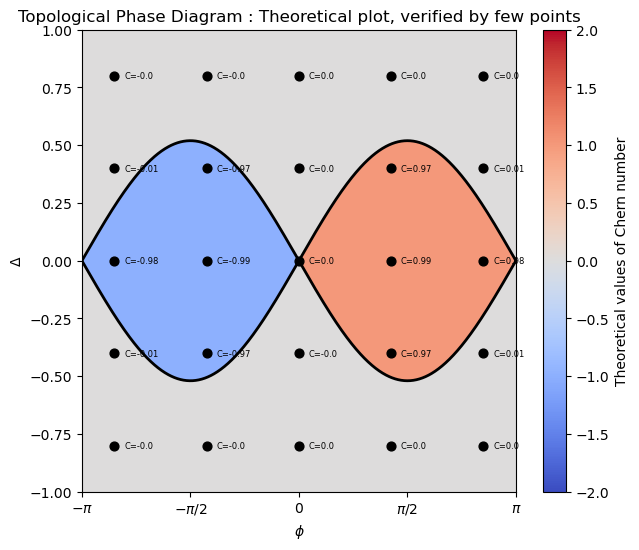

In [ ]:
phi_vals = np.linspace(-np.pi, np.pi, 400)
delta_vals = np.linspace(-1, 1, 400)

PHI, DELTA = np.meshgrid(phi_vals, delta_vals)

boundary = 3*np.sqrt(3)*t2*np.sin(PHI)

chern = np.zeros_like(PHI)

# topological regions
chern[(np.abs(DELTA) < np.abs(boundary)) & (np.sin(PHI) > 0)] = 1
chern[(np.abs(DELTA) < np.abs(boundary)) & (np.sin(PHI) < 0)] = -1

plt.figure(figsize=(7,6))

plt.pcolormesh(
    PHI, DELTA, chern,
    cmap="coolwarm",
    shading="auto",
    vmin=-2, vmax=2
)

# phase boundaries
phi_line = np.linspace(-np.pi,np.pi,1000)
b = 3*np.sqrt(3)*t2*np.sin(phi_line)

plt.plot(phi_line, b, 'k', lw=2)
plt.plot(phi_line, -b, 'k', lw=2)

plt.colorbar(label="Theoretical values of Chern number")

plt.xlabel(r"$\phi$")
plt.ylabel(r"$\Delta$")
plt.title("Topological Phase Diagram : Theoretical plot, verified by few points")

plt.xlim(-np.pi,np.pi)
plt.ylim(-1,1)

plt.xticks(
    [-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
    [r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"]
)

for (d,p), C in zip(test_points_grid, chern_vals):

    plt.scatter(p, d, color='black', s=40)

    plt.annotate(
        f"C={C}",
        (p,d),
        xytext=(7,-2),
        textcoords="offset points",
        fontsize=6
    )

plt.show()

In [75]:
def Hk_arb(kx, ky, phi0, delta0):

    g = 0+0j
    for a in avec:
        g += np.exp(1j*(kx*a[0] + ky*a[1]))
    g *= t1

    f = 0.0
    h0 = 0.0

    for b in bvec:
        kdot = kx*b[0] + ky*b[1]
        f  += np.sin(kdot)
        h0 += np.cos(kdot)

    f  *= 2*t2*np.sin(phi0)   # sigma_z term
    h0 *= 2*t2*np.cos(phi0)   # identity term
    
    H = np.array([
        [delta0 + f + h0, g],
        [np.conj(g), -delta0 - f + h0]
    ], dtype=complex)

    return H

def berry_curvature_arb(kx, ky, dkx, dky, phi0, delta0):

    H = Hk_arb(kx, ky, phi0, delta0)

    # eigenvalues and eigenvectors
    E, U = np.linalg.eigh(H)

    # Hamiltonian derivatives
    Hx = (Hk_arb(kx+dkx, ky, phi0, delta0) - Hk_arb(kx-dkx, ky, phi0, delta0))/(2*dkx)
    Hy = (Hk_arb(kx, ky+dky, phi0, delta0) - Hk_arb(kx, ky-dky, phi0, delta0))/(2*dky)

    F = np.zeros(2)

    for n in range(2):
        for m in range(2):
            if m != n:

                num = np.vdot(U[:,n], Hx @ U[:,m]) * \
                      np.vdot(U[:,m], Hy @ U[:,n])

                F[n] += -2*np.imag(num) / (E[m]-E[n])**2
    return F

In [70]:
# rec_vec_1=(2*np.pi/3)*np.array([np.sqrt(3),1])
# rec_vec_2=(2*np.pi/3)*np.array([np.sqrt(3),-1])
# dA=abs(np.cross(rec_vec_1,rec_vec_2))/n**2

# def chern_simplified(phi, delta, dA):

#     F_lower = np.zeros((Nk,Nk))

#     for i in range(Nk):
#         for j in range(Nk):
#             kx=i*rec_vec_1[0]+j*rec_vec_2[0]
#             ky=i*rec_vec_1[1]+j*rec_vec_2[1]
#             F = berry_curvature(kx, ky, dk)
#             F_lower[i,j] = F[0]
#     chern = np.sum(F)
    
#     chern *= dkx*dky/(2*np.pi)
#     return chern

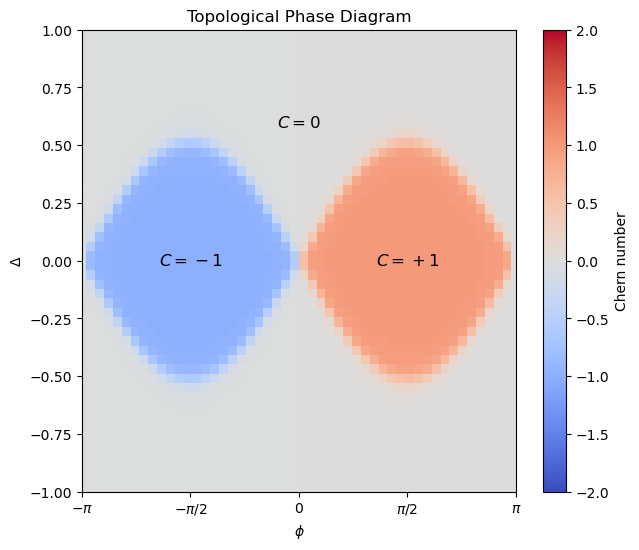

In [80]:
n=50
Nk=100
kx_vals = np.linspace(-np.pi, np.pi, Nk)
ky_vals = np.linspace(-np.pi, np.pi, Nk)

dkx = kx_vals[1] - kx_vals[0]
dky = ky_vals[1] - ky_vals[0]

phi_grid = np.linspace(-np.pi, np.pi, n)
delta_grid = np.linspace(-1, 1, n)

PHI, DELTA = np.meshgrid(phi_grid, delta_grid)

chern=np.zeros_like(PHI)

for p in range(len(delta_grid)):
    for q in range(len(phi_grid)):

        chern_pq = 0

        for i in range(Nk):
            for j in range(Nk):

                kx = kx_vals[i]
                ky = ky_vals[j]

                if inside_BZ(kx,ky):

                    F = berry_curvature_arb(kx, ky, dkx, dky, PHI[p,q], DELTA[p,q])
                    chern_pq += F[0]

        chern[p,q] = chern_pq * dkx*dky/(2*np.pi)


plt.figure(figsize=(7,6))
plt.pcolormesh(
    PHI, DELTA, chern,
    cmap="coolwarm",
    shading="auto",
    vmin=-2, vmax=2
)


plt.colorbar(label="Chern number")

plt.xlabel(r"$\phi$")
plt.ylabel(r"$\Delta$")
plt.title("Topological Phase Diagram")

plt.xlim(-np.pi,np.pi)
plt.ylim(-1,1)

plt.xticks(
    [-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
    [r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"]
)

# Add labels for Chern number regions
plt.text(-1.57, 0, r"$C = -1$", color='black', fontsize=12, ha='center', va='center')
plt.text(0, 0.6, r"$C = 0$", color='black', fontsize=12, ha='center', va='center')
plt.text(1.57, 0, r"$C = +1$", color='black', fontsize=12, ha='center', va='center')

plt.show()